# CSE 2600 Homework 1

### Magdalena Danielewicz 

In [11]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Question 1  

#### a. What is the mean of the data? What is the median?
Mean = 29.7, Median = 25 

#### b.	What is the mode of the data? Comment on the data’s modality (i.e., bimodal, trimodal, etc.).
Mode = 33. This data is unimodal, since 33 is the only number repeated 4 times.  

#### c.	Can you find (roughly) the first quartile (Q1) and the third quartile (Q3) of the data?
Q1 = 20, Q3 = 35  

#### d.	Give the five-number summary of the data.
Minimum: 13		Q1: 20		Q2: 25		Q3: 35		Maximum: 70  

#### e. Produce a boxplot of the data.

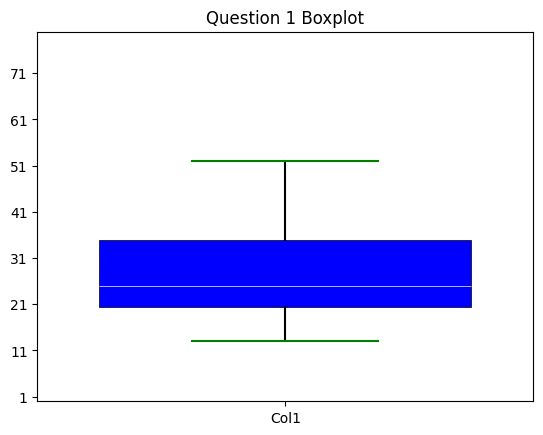

In [12]:
data = [13, 15, 16, 16, 19, 20, 20, 21, 22, 22, 23, 25, 25, 25, 30, 33,
33, 33, 33, 35, 35, 36, 40, 45, 46, 52, 70]


fig, ax = plt.subplots()
ax.boxplot(data,
           positions=[1],
           widths=0.75,
           patch_artist=True,
           showmeans=False,
           showfliers=False,
           medianprops={"color": "white", "linewidth": 0.5},
           boxprops={"facecolor": "blue", "edgecolor": "black", "linewidth": 0.5},
           whiskerprops={"color": "black", "linewidth": 1.5}, 
           capprops={"color": "green", "linewidth": 1.5})

ax.set(xlim=(0.5, 1.5), 
       ylim=(0, 80), yticks=np.arange(1, 81, 10))
ax.set(xticks=[1], xticklabels=["Col1"])
ax.set_title("Question 1 Boxplot")

plt.show()

# Question 2  


#### a.	How many rows are in this data set? How many columns?
322 rows, 20 columns  

#### b. From what year(s) is this data? What is the difference betw
This data is from 1986 and 1987. HmRun is the number of home runs in 1986, while CHmRun is the numbers of home runs during the career  

#### c. Find the median of each numeric variable.

In [13]:
hitters = pd.read_csv("../homeworks/hw-1/Hitters.csv") 

number_cols = hitters.select_dtypes(include='number')
medians = number_cols.median()
print(medians)

AtBat       379.5
Hits         96.0
HmRun         8.0
Runs         48.0
RBI          44.0
Walks        35.0
Years         6.0
CAtBat     1928.0
CHits       508.0
CHmRun       37.5
CRuns       247.0
CRBI        220.5
CWalks      170.5
PutOuts     212.0
Assists      39.5
Errors        6.0
Salary      425.0
dtype: float64


#### d. Create a pie chart that takes the total of AtBat in 1986 and displays what portion corresponded to Hits, Walks, or neither.

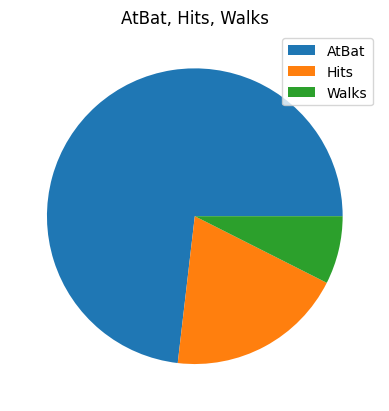

In [14]:
atBat = hitters["AtBat"].sum()
hit = hitters["Hits"].sum()
walks = hitters["Walks"].sum()

numbers = [atBat, hit, walks]
labels = ["AtBat", "Hits", "Walks"]

plt.pie(numbers)
plt.title("AtBat, Hits, Walks")
plt.legend(labels, loc="best")
plt.show()

#### e. How many rows are missing Salary information? What can you say about these players relative to those who have recorded salaries?
59 rows missing from Salary. Through the summed values, it can be seen that players with salaries have a higher average for both AtBat and Hits, even though players with salaries have a higher average of years spent in the league. 

In [15]:

na_salary_rows = hitters["Salary"].isna().sum()
total_rows = len(hitters)
print(f"Missing Salary: {na_salary_rows}\n")

print("Sums of players with Salary:")
print(hitters[hitters["Salary"].notna()][["AtBat","Hits","Years"]].describe(), "\n")

print("Sums of players without Salary:")
print(hitters[hitters["Salary"].isna()][["AtBat","Hits","Years"]].describe())


Missing Salary: 59

Sums of players with Salary:
            AtBat        Hits       Years
count  263.000000  263.000000  263.000000
mean   403.642586  107.828897    7.311787
std    147.307209   45.125326    4.793616
min     19.000000    1.000000    1.000000
25%    282.500000   71.500000    4.000000
50%    413.000000  103.000000    6.000000
75%    526.000000  141.500000   10.000000
max    687.000000  238.000000   24.000000 

Sums of players without Salary:
            AtBat        Hits      Years
count   59.000000   59.000000  59.000000
mean   279.677966   70.694915   8.033898
std    139.477898   39.994075   5.483411
min     16.000000    2.000000   1.000000
25%    197.500000   45.500000   4.000000
50%    249.000000   61.000000   7.000000
75%    352.500000   94.000000  12.000000
max    580.000000  194.000000  23.000000


#### f. Create a histogram for Salary across all records with non-missing values.

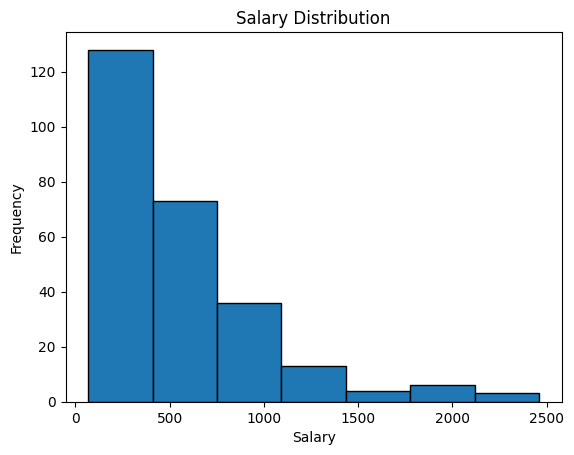

In [16]:
salary_rows = hitters["Salary"].dropna()

histogram = plt.hist(salary_rows, bins=7, edgecolor='black')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

#### g. Make pairwise scatterplots for each of the 6 career metrics with Salary.

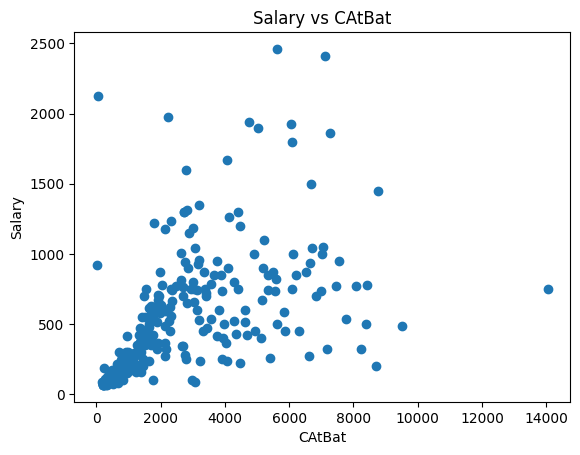

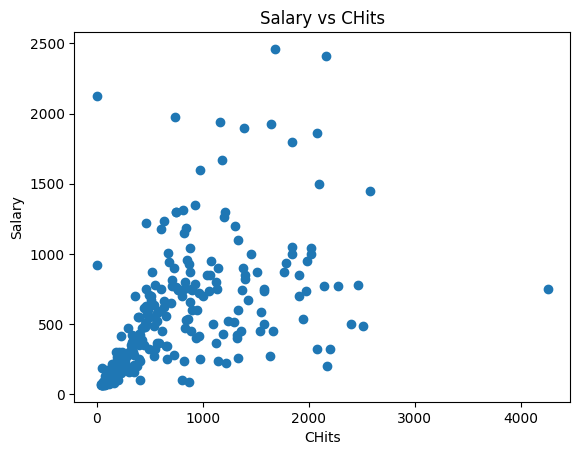

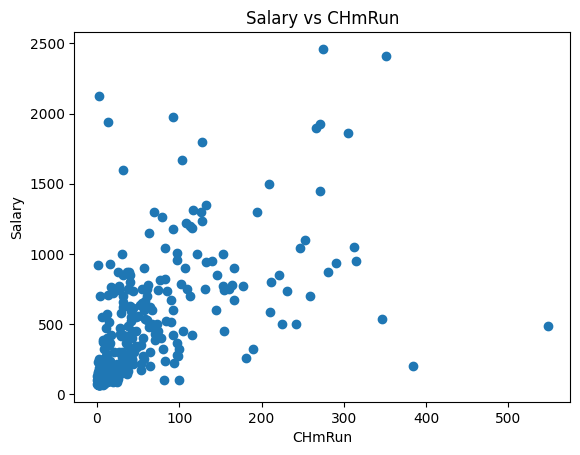

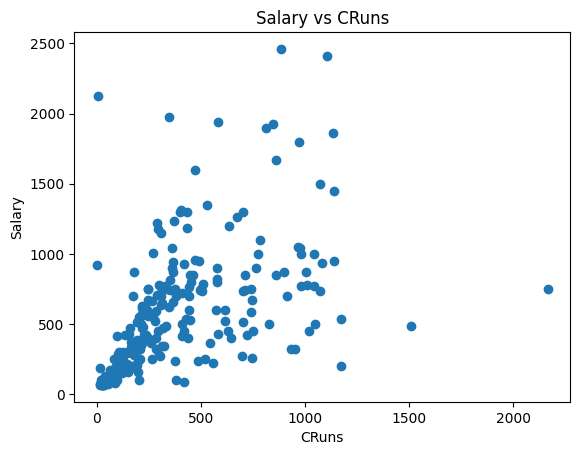

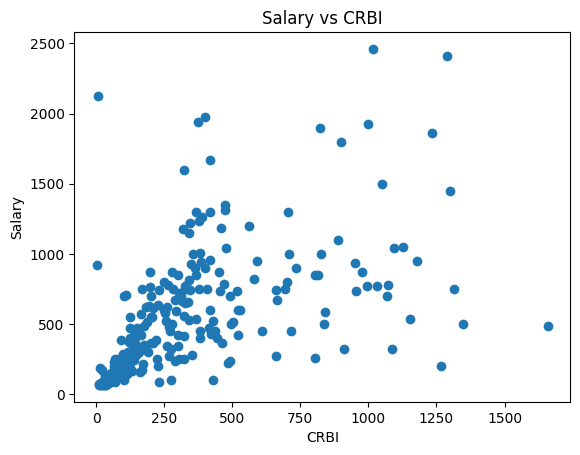

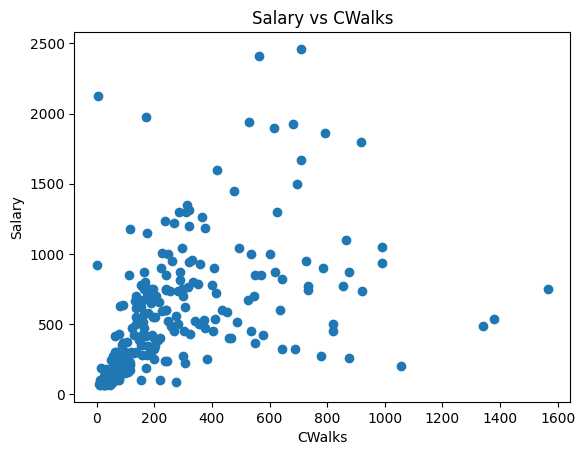

In [17]:
metrics = ["CAtBat", "CHits", "CHmRun", "CRuns", "CRBI", "CWalks"]
salary = hitters["Salary"]

for m in metrics:
    plt.scatter(hitters[m], salary)
    plt.title(f"Salary vs {m}")
    plt.xlabel(m)
    plt.ylabel("Salary")
    plt.show()

#### h. Calculate the mean salary for each division. Which division spends more on salaries? How much? Answer in total dollars rather than a per-player average.
Division E spends more on salaries, around $175 more than the mean of W. In total, Division E spends $20,114 more than Division W on salaries.

In [18]:
division_salary_means = hitters.groupby("Division")["Salary"].mean()

total_salary = hitters.groupby("Division")["Salary"].sum()

print(division_salary_means)
print("\n")
print(total_salary)



Division
E    624.271364
W    450.876873
Name: Salary, dtype: float64


Division
E    80531.006
W    60417.501
Name: Salary, dtype: float64


#### i. Provide boxplots for Salary for players with tenure greater than 12 years versus less than 5 years. What can you conclude?
From the comparison of these two boxplots, it is clear that the amount of years spent in the league affects the salary. The minimum of the boxplot for greater than 12 years is higher than the median of the less than 5 years boxplot. The 12 year's interquartile range is even completely above the maximum of the 5 year plot. The more years spent in the league means a higher salary.

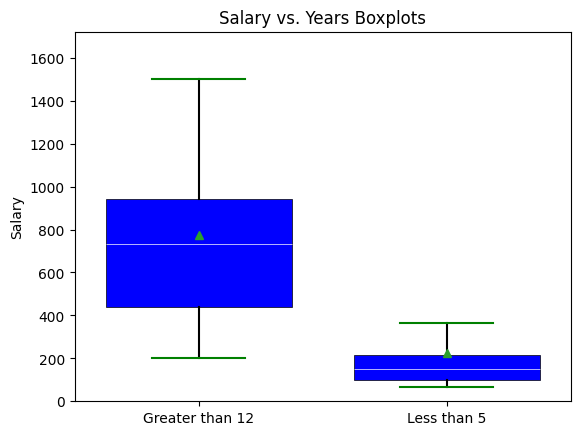

In [19]:
above_12_years = hitters.loc[hitters["Years"] > 12, "Salary"].dropna()
less_5_years = hitters.loc[hitters["Years"] < 5, "Salary"].dropna()

data = [above_12_years, less_5_years]

fig, ax = plt.subplots()
ax.boxplot(data,
           positions=[1, 2],
           widths=0.75,
           patch_artist=True,
           showmeans=True,
           showfliers=False,
           medianprops={"color": "white", "linewidth": 0.5},
           boxprops={"facecolor": "blue", "edgecolor": "black", "linewidth": 0.5},
           whiskerprops={"color": "black", "linewidth": 1.5}, 
           capprops={"color": "green", "linewidth": 1.5})

ax.set(xlim=(0.5, 2.5), 
       ylim=(0, max(hitters["Salary"].dropna())*0.7))
ax.set(xticks=[1, 2], xticklabels=["Greater than 12", "Less than 5"])
ax.set_title("Salary vs. Years Boxplots")
plt.ylabel("Salary")

plt.show()

#### j. Which player has the highest batting average (number of hits per at-bat) during his career? Provide the league, division, salary, and career batting average of this player.
Player record 22 has the highest batting average with a ratio of 0.45. This player is in league A, division W, and does not have a recorded salary.

#### k. Comment on the players who have the 5 highest career batting averages in this dataset. Do they have similar stats? Are there meaningful differences?

There are some noticable differences and similarities here. First off, the top 2 players with the highest batting averages has significantly less amounts of AtBat's and Hits, being in double digits while the other 3 players are in the triples digits within a range of 306 to 677. The top 2 players are also the only 2 with no salary, even though they have around the same amount of years as the other 3 players. A majority of the players are in the league A and division E. 

In [20]:
atBat = hitters["AtBat"]
hit = hitters["Hits"]

highest = 0

for i in range(len(atBat)):
    if atBat[i] != 0:
        ratio = hit[i] / atBat[i]
        if ratio > highest:
            highest = ratio
            player = i
        else:
            continue


print(f"Player with highest Hits/AtBat ratio is player {player} with ratio {highest}\n")

best_player = hitters.loc[hitters["AtBat"] == player]
print(f"League: {best_player['League'].values[0]}\nDivision: {best_player['Division'].values[0]}\nSalary: {best_player['Salary'].values[0]}\nCareer batting average: {highest}")

top_5 = hitters.nlargest(5, "Hits")

hitters["BattingAverage"] = hitters["Hits"] / hitters["AtBat"]
top_5 = hitters.sort_values("BattingAverage", ascending=False).head(5)
print(top_5[["AtBat", "Hits", "BattingAverage", "League", "Division", "Salary", "Years"]])



Player with highest Hits/AtBat ratio is player 22 with ratio 0.45454545454545453

League: A
Division: W
Salary: nan
Career batting average: 0.45454545454545453
     AtBat  Hits  BattingAverage League Division  Salary  Years
22      22    10        0.454545      A        W     NaN      6
52      19     7        0.368421      A        E     NaN      4
313    580   207        0.356897      A        E  1600.0      5
82     677   238        0.351551      A        E  1975.0      5
130    306   104        0.339869      N        E   750.0      7


# Question 3

#### a. The sample size n is extremely large, and the number of predictors p is small.

A flexible method for this would be best. If the sample size is much larger than the amount of predictors, then there's less of a chance of noise appearing in the data and affecting a representation of it, meaning there's low variance and inflexible methods may underfit, or apply too much bias.

#### b. The number of predictors p is extremely large, and the number of observations n is small.

An inflexible method here would be best. If there is more predictors than there are observations, then the data is prone to being much more varied. An inflexible method here would make sure that the data doesn't get too overcrowded and messy, controlling variance and making sure that it won't be overfitted.

#### c. The relationship between the predictors and response is highly non-linear.

A flexible method must be used. If an inflexible method is used, then the model would have too high of a bias. A non-linear structure can't be defined by rigid linear methods, such as an inflexible model.

#### d. The variance of the error terms, i.e. σ2 = Var(ε) is extremely high.

This scenario should use an inflexible method. With a high variance, there would be too much noise in the relationships of the data and the errors would be all over the place. An inflexible method would result in overfitting.
    


# Question 4

#### a. A researcher collects data on 600 high school students across the country. For each student, they record GPA, number of hours spent studying per week, parental education level, and SAT score. The goal is to understand what factors influence SAT score.

This scenario is a regression problem where we are most interested in inference. We are trying to predict a numeric value of a quantitative SAT score, and attemping to answer the question of why these SAT scores are that they are, which ends up being inference.

#### b. A hospital wants to identify which factors are associated with patient readmission within 30 days of discharge. Data is collected on 2,000 past patients. For each, the hospital records readmission status (yes/no), age, number of prior visits, length of stay, diagnosis type, and insurance type.

Here, it's seen that this problem is a classification problem in which we are trying to predict whether or not a patient will be readmitted within 30 days, which is a categorical outcome. We are interested in inference here, as we are taking a look at which factors lead to this and understanding them, not only focusing on forecasting the outcome.

#### c. A start-up wants to predict whether a crowdfunding campaign will reach its funding goal. They gather data on 45 past campaigns. For each campaign, they have data on whether the goal was reached or not, campaign duration, number of backers, video length, and eight other variables. The primary goal is to accurately predict outcomes for future campaigns.

In this scenario, we are looking at a classification problem with an interest in prediction. We are looking towards a numeric funding goal and if the campaign reached the goal. Our main concern isn't why the funding goal was or wasn't reached, it's whether or not it'll be reached based on the data.

#### d. An energy company collects daily data over the course of one year to model daily electricity consumption. For each day, they record total consumption (in MWh), average temperature, day of the week, and humidity level. The goal is to forecast daily consumption based on weather and calendar factors.

This scenario is another regression problem with an interest in prediction. The outcome here is a numeric value of daily consumption in MWh. The goal is focused on forecasting, or predicting, the daily consumption.